In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [13]:
# Define objective function for c=1.5
def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params(filename):
    """Extract parameters from filename"""
    # For 2nd order (with initial_velocity)
    match_with_velocity = re.search(
        r'initial_theta_([-\d.]+?)_initial_velocity_([-\d.]+?)_lr_([\d.]+?)_beta1_([\d.]+?)_beta2_([\d.]+?)\.csv',
        filename
    )
    
    if match_with_velocity:
        return {
            'initial_theta': float(match_with_velocity.group(1)),
            'initial_velocity': float(match_with_velocity.group(2)),
            'lr': float(match_with_velocity.group(3)),
            'beta1': float(match_with_velocity.group(4)),
            'beta2': float(match_with_velocity.group(5))
        }
    
    # For 1st order or discrete (without initial_velocity)
    match_without_velocity = re.search(
        r'initial_theta_([-\d.]+?)_lr_([\d.]+?)_beta1_([\d.]+?)_beta2_([\d.]+?)\.csv',
        filename
    )
    
    if match_without_velocity:
        return {
            'initial_theta': float(match_without_velocity.group(1)),
            'initial_velocity': None,
            'lr': float(match_without_velocity.group(2)),
            'beta1': float(match_without_velocity.group(3)),
            'beta2': float(match_without_velocity.group(4))
        }
    
    return None

def calculate_errors(theta_discrete, theta_continuous, c=1.5, alpha=None, T=None, delta=0.0):
    """
    Calculate E_inf and E_f for two 1D theta sequences over a fixed physical time horizon.
    
    Compares discrete values theta_k with continuous values theta(t_k) 
    using the matching t_k = k * alpha. Always uses Rosenbrock function for E_f.
    
    Parameters:
    -----------
    theta_discrete : array-like
        Discrete values theta_k (1D array)
    theta_continuous : array-like
        Continuous values theta(t_k) (1D array)
    c : float, optional
        Rosenbrock function parameter (default: 1.5)
    alpha : float, optional
        Learning rate (step size). If None, uses full available data.
    T : float, optional
        Final physical time. If provided, defines K = floor(T/alpha). Requires alpha.
    delta : float, optional
        Burn-in time to skip. Defines k0 = ceil(delta/alpha). Requires alpha. Default: 0.0
    
    Returns:
    --------
    E_inf : float
        max_{k0 <= k <= K} |theta_k - theta(t_k)|
    E_f : float
        max_{k0 <= k <= K} |f(theta_k) - f(theta(t_k))| where f is Rosenbrock
    info : dict
        Metadata: 'k0', 'K', 'T_used', 'n_points', 'alpha', 'delta'
    """
    
    # Validations
    if T is not None and alpha is None:
        raise ValueError("Parameter 'T' requires 'alpha' to be specified")
    
    if delta > 0 and alpha is None:
        raise ValueError("Parameter 'delta' (burn-in) requires 'alpha' to be specified")
    
    if T is not None and delta >= T:
        raise ValueError(f"Burn-in time delta={delta} must be < T={T}")
    
    # Convert to numpy arrays
    theta_d = np.asarray(theta_discrete)
    theta_c = np.asarray(theta_continuous)
    
    # Determine index range
    min_len = min(len(theta_d), len(theta_c))
    
    if min_len == 0:
        raise ValueError("Input sequences are empty")
    
    # Starting index k0 (after burn-in)
    k0 = 0
    if delta > 0 and alpha is not None:
        k0 = int(np.ceil(delta / alpha))
    
    # Final index K (based on time horizon or available data)
    K = min_len - 1
    if T is not None and alpha is not None:
        K = min(int(np.floor(T / alpha)), min_len - 1)
    
    # Check we have data
    if k0 > K:
        raise ValueError(
            f"No data points available: k0={k0} > K={K}. "
            f"Reduce delta or increase T/data length."
        )
    
    # Slice the data
    theta_d_slice = theta_d[k0:K+1]
    theta_c_slice = theta_c[k0:K+1]
    n_points = len(theta_d_slice)
    
    # Calculate E_inf
    E_inf = np.max(np.abs(theta_d_slice - theta_c_slice))
    
    # Calculate E_f using Rosenbrock function
    f_discrete = f_rosenbrock(theta_d_slice, c=c)
    f_continuous = f_rosenbrock(theta_c_slice, c=c)
    E_f = np.max(np.abs(f_discrete - f_continuous))
    
    # Compute actual physical time used
    T_used = K * alpha if alpha is not None else None
    
    # Build info dictionary
    info = {
        'k0': k0,
        'K': K,
        'T_used': T_used,
        'n_points': n_points,
        'alpha': alpha,
        'delta': delta
    }
    
    return E_inf, E_f, info

In [14]:
# Configuration: theta_initial = -1.5, fixed betas
target_initial_theta = -1.5
target_beta1 = 0.99
target_beta2 = 0.999
c_value = 1.5
T_horizon = 3.3  
delta_burnin = 0.5 


# Directories
results_dir = Path("results")
results_1st_order_dir = Path("results_1rst_order")
results_2nd_order_dir = Path("results_2nd_order")

In [15]:
# Read ALL discrete files
discrete_data_dict = {}
discrete_files = list(results_dir.glob("*.csv"))

for csv_file in discrete_files:
    params = extract_params(str(csv_file))
    if (params and 
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        discrete_data_dict[lr] = pd.read_csv(csv_file)
        print(f"Discrete file found: {csv_file.name}, lr={lr}")

# Read 1st order files
results_1st_order = {}
continuous_1st_files = list(results_1st_order_dir.glob("*.csv"))

for csv_file in continuous_1st_files:
    params = extract_params(str(csv_file))
    if (params and 
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        data = pd.read_csv(csv_file)
        results_1st_order[lr] = data
        print(f"1st order file found: {csv_file.name}, lr={lr}")

# Read 2nd order files
results_2nd_order = {}
continuous_2nd_files = list(results_2nd_order_dir.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params(str(csv_file))
    if (params and 
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        initial_velocity = params['initial_velocity']
        
        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        
        data = pd.read_csv(csv_file)
        results_2nd_order[lr][initial_velocity] = data
        print(f"2nd order file found: {csv_file.name}, lr={lr}, v0={initial_velocity}")

Discrete file found: discrete_adam_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
Discrete file found: discrete_adam_results_initial_theta_-1.5_lr_0.0005_beta1_0.99_beta2_0.999.csv, lr=0.0005
Discrete file found: discrete_adam_results_initial_theta_-1.5_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
Discrete file found: discrete_adam_results_initial_theta_-1.5_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
Discrete file found: discrete_adam_results_initial_theta_-1.5_lr_0.0001_beta1_0.99_beta2_0.999.csv, lr=0.0001
1st order file found: continuous_adam_results_initial_theta_-1.5_lr_0.0001_beta1_0.99_beta2_0.999.csv, lr=0.0001
1st order file found: continuous_adam_results_initial_theta_-1.5_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
1st order file found: continuous_adam_results_initial_theta_-1.5_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
1st order file found: continuous_adam_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
1st order file

In [16]:
# Calculate errors comparing discrete vs continuous with SAME learning rate
print("\n" + "="*60)
print("CALCULATING ERRORS (Discrete vs Continuous for same α)")
print("="*60)

# Common learning rates between discrete and 1st order
common_lrs = sorted(set(discrete_data_dict.keys()) & set(results_1st_order.keys()))
print(f"\nCommon learning rates: {common_lrs}\n")

# Calculate errors for 1st order
print("1ST ORDER RESULTS")
print("-"*60)
lrs_1st = []
E_inf_1st = []
E_f_1st = []
table_1st_order = []

for lr in common_lrs:
    discrete_data = discrete_data_dict[lr]
    continuous_data = results_1st_order[lr]
    
    theta_discrete = discrete_data['theta_history'].values
    theta_continuous = continuous_data['theta_history'].values
    
    E_inf, E_f, info = calculate_errors(
        theta_discrete, theta_continuous, 
        c=c_value, 
        alpha=lr, 
        T=T_horizon, 
        delta=delta_burnin
    )
    
    lrs_1st.append(lr)
    E_inf_1st.append(E_inf)
    E_f_1st.append(E_f)
    
    table_1st_order.append({
        'lr': lr,
        'E_inf': E_inf,
        'E_f': E_f,
        'n_points': info['n_points'],
        'T_used': info['T_used']
    })
    
    print(f"lr={lr}: E_inf={E_inf:.6e}, E_f={E_f:.6e}, n_points={info['n_points']}")

# Calculate errors for 2nd order
print("\n2ND ORDER RESULTS")
print("-"*60)
E_inf_2nd_dict = {}
E_f_2nd_dict = {}
lrs_2nd_dict = {}
table_2nd_order = []

for lr in common_lrs:
    if lr in results_2nd_order:
        for v0 in sorted(results_2nd_order[lr].keys()):
            if v0 not in E_inf_2nd_dict:
                E_inf_2nd_dict[v0] = []
                E_f_2nd_dict[v0] = []
                lrs_2nd_dict[v0] = []
            
            discrete_data = discrete_data_dict[lr]
            continuous_data = results_2nd_order[lr][v0]
            
            theta_discrete = discrete_data['theta_history'].values
            theta_continuous = continuous_data['theta_history'].values
            
            E_inf, E_f, info = calculate_errors(
                theta_discrete, theta_continuous, 
                c=c_value, 
                alpha=lr, 
                T=T_horizon, 
                delta=delta_burnin
            )
            
            E_inf_2nd_dict[v0].append(E_inf)
            E_f_2nd_dict[v0].append(E_f)
            lrs_2nd_dict[v0].append(lr)
            
            table_2nd_order.append({
                'lr': lr,
                'initial_velocity': v0,
                'E_inf': E_inf,
                'E_f': E_f,
                'n_points': info['n_points'],
                'T_used': info['T_used']
            })
            
            print(f"lr={lr}, v0={v0}: E_inf={E_inf:.6e}, E_f={E_f:.6e}, n_points={info['n_points']}")

# Create and display tables
df_1st_order = pd.DataFrame(table_1st_order)
df_2nd_order = pd.DataFrame(table_2nd_order)

print("\n" + "="*60)
print("1ST ORDER TABLE")
print("="*60)
print(df_1st_order.to_string(index=False))

print("\n" + "="*60)
print("2ND ORDER TABLE")
print("="*60)
print(df_2nd_order.to_string(index=False))

# Save tables
df_1st_order.to_csv("errors/error_table_1st_order.csv", index=False)
df_2nd_order.to_csv("errors/error_table_2nd_order.csv", index=False)
print("\n✓ Tables saved to errors/ directory")


CALCULATING ERRORS (Discrete vs Continuous for same α)

Common learning rates: [0.0001, 0.0005, 0.001, 0.005, 0.01]

1ST ORDER RESULTS
------------------------------------------------------------
lr=0.0001: E_inf=5.063445e-04, E_f=1.463482e-03, n_points=28001
lr=0.0005: E_inf=5.822794e-03, E_f=1.868100e-02, n_points=5600
lr=0.001: E_inf=8.090658e-03, E_f=1.466772e-02, n_points=2800
lr=0.005: E_inf=2.132128e-02, E_f=6.135431e-02, n_points=561
lr=0.01: E_inf=3.984172e-02, E_f=1.293362e-01, n_points=281

2ND ORDER RESULTS
------------------------------------------------------------
lr=0.0001, v0=-1.0: E_inf=9.133209e-03, E_f=2.943664e-02, n_points=28001
lr=0.0001, v0=0.0: E_inf=9.144840e-03, E_f=2.948421e-02, n_points=28001
lr=0.0001, v0=1.0: E_inf=9.215317e-03, E_f=2.972308e-02, n_points=28001
lr=0.0001, v0=2.0: E_inf=9.326843e-03, E_f=3.009500e-02, n_points=28001
lr=0.0005, v0=-1.0: E_inf=6.335742e-03, E_f=2.011029e-02, n_points=5600
lr=0.0005, v0=0.0: E_inf=6.967850e-03, E_f=2.234801e


✓ Gráficas guardadas en plots/error_loglog_comparison.png


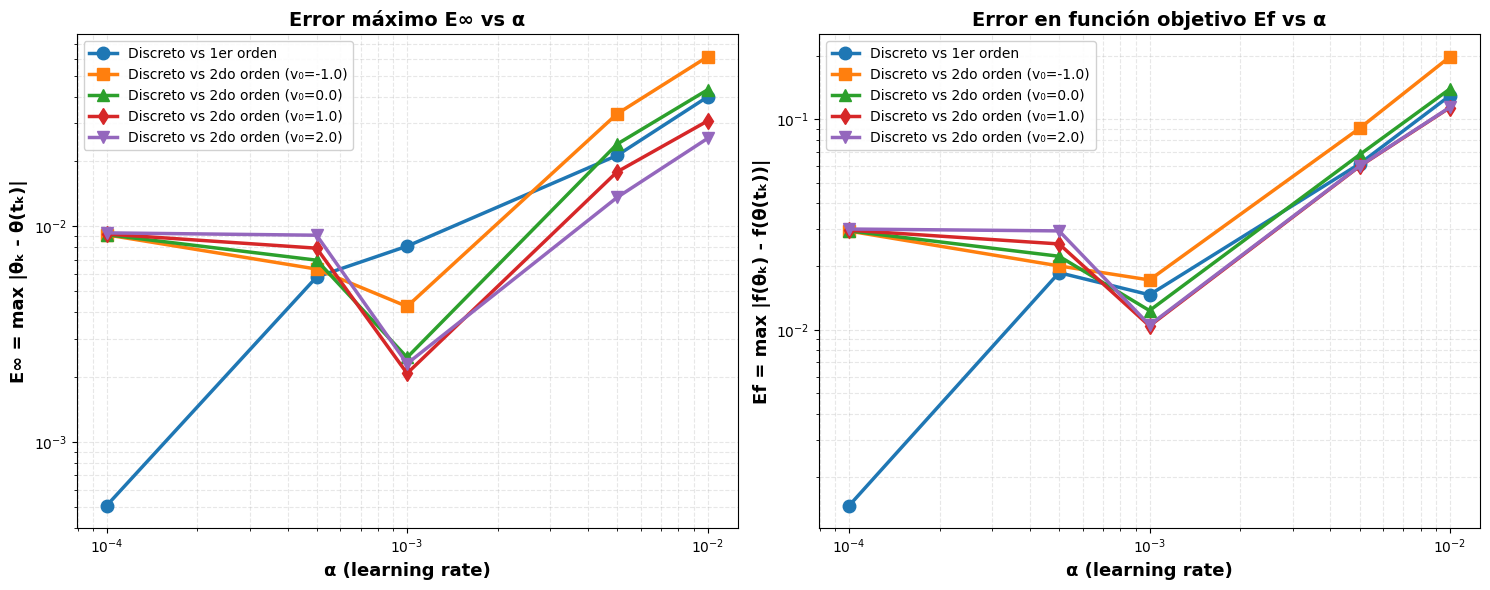

In [17]:
# Create log-log plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: E_inf(α)
ax1.loglog(lrs_1st, E_inf_1st, 'o-', label='Discreto vs 1er orden', 
          linewidth=2.5, markersize=9, color='C0')

colors = ['C1', 'C2', 'C3', 'C4']
markers = ['s', '^', 'd', 'v']
for i, v0 in enumerate(sorted(E_inf_2nd_dict.keys())):
    ax1.loglog(lrs_2nd_dict[v0], E_inf_2nd_dict[v0], 
              marker=markers[i % len(markers)], linestyle='-',
              label=f'Discreto vs 2do orden (v₀={v0})', 
              linewidth=2.5, markersize=8, color=colors[i % len(colors)])

ax1.set_xlabel('α (learning rate)', fontsize=13, fontweight='bold')
ax1.set_ylabel('E∞ = max |θₖ - θ(tₖ)|', fontsize=13, fontweight='bold')
ax1.set_title('Error máximo E∞ vs α', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3, which='both', linestyle='--')

# Plot 2: E_f(α)
ax2.loglog(lrs_1st, E_f_1st, 'o-', label='Discreto vs 1er orden', 
          linewidth=2.5, markersize=9, color='C0')

for i, v0 in enumerate(sorted(E_f_2nd_dict.keys())):
    ax2.loglog(lrs_2nd_dict[v0], E_f_2nd_dict[v0], 
              marker=markers[i % len(markers)], linestyle='-',
              label=f'Discreto vs 2do orden (v₀={v0})', 
              linewidth=2.5, markersize=8, color=colors[i % len(colors)])

ax2.set_xlabel('α (learning rate)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Ef = max |f(θₖ) - f(θ(tₖ))|', fontsize=13, fontweight='bold')
ax2.set_title('Error en función objetivo Ef vs α', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, which='both', linestyle='--')

plt.tight_layout()

# Save plots
plt.savefig('plots/error_loglog_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráficas guardadas en plots/error_loglog_comparison.png")
plt.show()